In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
np.random.seed(42)


# 1. Load individual data sets

### Rito et al. 2025 (3D notoroid)
________________________________

In [2]:
adata_notoroid = sc.read_mtx("./Rito_et_al_2025/GSE255338_notoroid_raw_counts.mtx.gz")
adata_notoroid = adata_notoroid.transpose()
adata_notoroid.obs_names_make_unique()
adata_notoroid.var_names_make_unique()

In [3]:
cells = pd.read_table("./Rito_et_al_2025/GSE255338_notoroid_raw_counts_cells.csv", sep=',',header=0)['Unnamed: 0'].values
genes = pd.read_table("./Rito_et_al_2025/GSE255338_notoroid_raw_counts_genes.csv",  sep=',',header=0)['Unnamed: 0'].values
adata_notoroid.obs_names = cells
adata_notoroid.var_names = genes
adata_notoroid.obs['sample'] = pd.read_table("./Rito_et_al_2025/GSE255338_notoroid_raw_counts_cells.csv", sep=',',header=0)['sample'].values


In [4]:
#cells to look at 

stacked = np.vstack([np.squeeze(np.asarray(adata_notoroid[:,'{}'.format("FOXA2")].X.todense()))>0, 
                     np.squeeze(np.asarray(adata_notoroid[:,'{}'.format("SHH")].X.todense()))>0, 
                     np.squeeze(np.asarray(adata_notoroid[:,'{}'.format("NOTO")].X.todense()))>0])


adata_notoroid.obs["Noto_review"] = np.array( (np.sum(stacked, axis=0) >= 1) &\
(np.squeeze(np.asarray(adata_notoroid[:,'{}'.format("TBXT")].X.todense()))> 0) &\
(np.squeeze(np.asarray(adata_notoroid[:,'{}'.format("TBX6")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata_notoroid[:,'{}'.format("SOX17")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata_notoroid[:,'{}'.format("HAND1")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata_notoroid[:,'{}'.format("FOXC2")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata_notoroid[:,'{}'.format("SOX2")].X.todense()))== 0) , dtype="int")

print(f'Total of cells considered: {np.sum(np.asarray(adata_notoroid.obs["Noto_review"])==True)}')

adata_notoroid.obs.groupby(['sample', 'Noto_review']).size()

Total of cells considered: 699


sample  Noto_review
0       0              3478
        1               106
1       0              3539
        1               517
2       0              4876
        1                30
3       0              4313
        1                41
4       0              4115
5       0              5032
        1                 1
6       0              4886
        1                 4
dtype: int64

In [5]:
cell_list = adata_notoroid.obs.index[adata_notoroid.obs["Noto_review"]==True]
adata_rito3d = adata_notoroid[adata_notoroid.obs_names.isin(cell_list)]
adata_rito3d.obs.columns = adata_rito3d.obs.columns +"_rito3D"
adata_rito3d

View of AnnData object with n_obs × n_vars = 699 × 33538
    obs: 'sample_rito3D', 'Noto_review_rito3D'

### Rito et al. 2025 (2D micropatterns)
________________________________

In [6]:
adata_micropattern = sc.read_h5ad("./Rito_et_al_2025/GSE224404_posterior_neuruloid_data_file.h5ad")
adata_micropattern.obs_names_make_unique()
adata_micropattern.var_names_make_unique()

In [7]:
#cells to look at 

stacked = np.vstack([np.squeeze(np.asarray(adata_micropattern[:,'{}'.format("FOXA2")].X.todense()))>0, 
                     np.squeeze(np.asarray(adata_micropattern[:,'{}'.format("SHH")].X.todense()))>0, 
                     np.squeeze(np.asarray(adata_micropattern[:,'{}'.format("NOTO")].X.todense()))>0])


adata_micropattern.obs["Noto_review"] = np.array( (np.sum(stacked, axis=0) >= 1) &\
(np.squeeze(np.asarray(adata_micropattern[:,'{}'.format("TBXT")].X.todense())) > 0) &\
(np.squeeze(np.asarray(adata_micropattern[:,'{}'.format("TBX6")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata_micropattern[:,'{}'.format("SOX17")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata_micropattern[:,'{}'.format("HAND1")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata_micropattern[:,'{}'.format("FOXC2")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata_micropattern[:,'{}'.format("SOX2")].X.todense()))== 0) , dtype="int")

print(f'Total of cells considered: {np.sum(np.asarray(adata_micropattern.obs["Noto_review"])==True)}')
adata_micropattern.obs.groupby(['sample', 'Noto_review']).size()

Total of cells considered: 172


/tmp/slurm_44827182/ipykernel_1306977/3735867529.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_micropattern.obs.groupby(['sample', 'Noto_review']).size()


sample  Noto_review
0       0              3419
        1                 3
1       0              2029
        1               164
2       0              2172
        1                 5
dtype: int64

In [8]:
cell_list = adata_micropattern.obs.index[adata_micropattern.obs["Noto_review"]==True]
adata_ritom = adata_micropattern[adata_micropattern.obs_names.isin(cell_list)]
adata_ritom.obs.columns = adata_ritom.obs.columns +"_rito2D"
adata_ritom

View of AnnData object with n_obs × n_vars = 172 × 33538
    obs: 'n_genes_rito2D', 'n_genes_by_counts_rito2D', 'total_counts_rito2D', 'total_counts_mt_rito2D', 'pct_counts_mt_rito2D', 'doublet_rito2D', 'doublet_score_rito2D', 'sample_rito2D', 'Noto_review_rito2D'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2'

### Xu et al. 2023
________________________________

In [9]:
adata = sc.read_h5ad('../human_embryo_data/Xu_raw_data.h5ad')
adata.obs.index = adata.obs['cell_id']
adata.var.index = adata.var['gene_short_name']
adata.obs_names= adata.obs['cell_id']
adata.var_names = np.array(adata.var['gene_short_name'])
adata.var_names = adata.var_names.str.replace(r'\bT\b', 'TBXT', regex=True)
adata.obs_names_make_unique()
adata.var_names_make_unique()

/nemo/lab/briscoej/home/users/ritot/single_cell/env2/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/nemo/lab/briscoej/home/users/ritot/single_cell/env2/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [10]:
#cells to look at 
stacked = np.vstack([np.squeeze(np.asarray(adata[:,'{}'.format("FOXA2")].X.todense()))>0, 
                     np.squeeze(np.asarray(adata[:,'{}'.format("SHH")].X.todense()))>0, 
                     np.squeeze(np.asarray(adata[:,'{}'.format("NOTO")].X.todense()))>0])


adata.obs["Noto_review"] = np.array( (np.sum(stacked, axis=0) >= 1) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("TBXT")].X.todense())) > 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("TBX6")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("SOX17")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("HAND1")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("FOXC2")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("SOX2")].X.todense()))== 0) , dtype="int")

print(f'Total of cells considered: {np.sum(np.asarray(adata.obs["Noto_review"])==True)}')

adata.obs.groupby(['stage', 'Noto_review']).size()

Total of cells considered: 7


/tmp/slurm_44827182/ipykernel_1306977/3864102828.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(['stage', 'Noto_review']).size()


stage    Noto_review
CS12     0              18186
         1                  4
CS13     0              18995
         1                  2
CS15-16  0              66076
         1                  1
dtype: int64

In [11]:
cell_list = adata.obs.index[adata.obs["Noto_review"]==True]
adata_xu = adata[adata.obs_names.isin(cell_list)]
adata_xu.obs.columns = adata_xu.obs.columns +"_xu"
adata_xu

View of AnnData object with n_obs × n_vars = 7 × 33694
    obs: 'cell_id_xu', 'cluster_id_xu', 'main_cluster_xu', 'annotation_xu', 'embryo_xu', 'stage_xu', 'dissection_part_xu', 'Noto_review_xu'
    var: 'gene_id', 'gene_short_name'

### Yaman et al. 2023 
________________________________

In [12]:
adata = sc.read_mtx("./Yaman_et_al_2024/GSE220563_RAW/GSM6806916_matrix.mtx.gz")
adata = adata.transpose()

cells = pd.read_table("./Yaman_et_al_2024/GSE220563_RAW/GSM6806916_barcodes.tsv.gz", sep=',',header=None)[0].values
genes = pd.read_table("./Yaman_et_al_2024/GSE220563_RAW/GSM6806916_features.tsv.gz",   sep="\t", header=None)[1].values
adata.obs_names = cells
adata.var_names = genes
adata.obs_names_make_unique()
adata.var_names_make_unique()


In [13]:
#cells to look at 
stacked = np.vstack([np.squeeze(np.asarray(adata[:,'{}'.format("FOXA2")].X.todense()))>0, 
                     np.squeeze(np.asarray(adata[:,'{}'.format("SHH")].X.todense()))>0, 
                     np.squeeze(np.asarray(adata[:,'{}'.format("NOTO")].X.todense()))>0])


adata.obs["Noto_review"] = np.array( (np.sum(stacked, axis=0) >= 1) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("TBXT")].X.todense())) > 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("TBX6")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("SOX17")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("HAND1")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("FOXC2")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("SOX2")].X.todense()))== 0) , dtype="int")

print(f'Total of cells considered: {np.sum(np.asarray(adata.obs["Noto_review"])==True)}')


Total of cells considered: 42


In [14]:
cell_list = adata.obs.index[adata.obs["Noto_review"]==True]
adata_yaman = adata[adata.obs_names.isin(cell_list)]
adata_yaman.obs.columns = adata_yaman.obs.columns +"_yaman"
adata_yaman

View of AnnData object with n_obs × n_vars = 42 × 36601
    obs: 'Noto_review_yaman'

### Warin et al. 2024 (diffs)
________________________________

In [15]:
adata = sc.read_mtx("./files_julie/2023-03-27-Integration.by.Seurat.CFS.EU.SCT.CC.clustered_matrix.mtx")
adata = adata.transpose()
adata.obs_names_make_unique()
adata.var_names_make_unique()

In [16]:
cells = pd.read_table("./files_julie/2023-03-27-Integration.by.Seurat.CFS.EU.SCT.CC.clustered_barcodes.csv", sep=',',header=None)[0].values
genes = pd.read_table("./files_julie/2023-03-27-Integration.by.Seurat.CFS.EU.SCT.CC.clustered_features.csv",  sep=',',header=None)[0].values
adata.obs_names = cells 
adata.var_names = genes
adata.obs['sample']=[x.split('_')[0] for x in adata.obs_names ]

In [17]:
#cells to look at 

stacked = np.vstack([np.squeeze(np.asarray(adata[:,'{}'.format("FOXA2")].X.todense()))>0, 
                     np.squeeze(np.asarray(adata[:,'{}'.format("SHH")].X.todense()))>0, 
                     np.squeeze(np.asarray(adata[:,'{}'.format("NOTO")].X.todense()))>0])


adata.obs["Noto_review"] = np.array( (np.sum(stacked, axis=0) >= 1) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("TBXT")].X.todense())) > 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("TBX6")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("SOX17")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("HAND1")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("FOXC2")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("SOX2")].X.todense()))== 0) , dtype="int")

print(f'Total of cells considered: {np.sum(np.asarray(adata.obs["Noto_review"])==True)}')

adata.obs.groupby(['sample', 'Noto_review']).size()

Total of cells considered: 677


sample  Noto_review
CFS     0              9122
        1               340
EU      0              9407
        1               337
dtype: int64

In [18]:
cell_list = adata.obs.index[adata.obs["Noto_review"]==True]
adata_warindiff = adata[adata.obs_names.isin(cell_list)]
adata_warindiff.obs.columns = adata_warindiff.obs.columns +"_warin_diff"
adata_warindiff

View of AnnData object with n_obs × n_vars = 677 × 23766
    obs: 'sample_warin_diff', 'Noto_review_warin_diff'

### Warin et al. 2024 (embryo)
________________________________

In [19]:
import h5py
from scipy.sparse import csr_matrix

with h5py.File("./files_julie/GSM7623467_NCC_filtered_feature_bc_matrix.h5", "r") as f:
    #print(list(f["matrix"].keys()))
    data = f["matrix/data"][:]
    indices = f["matrix/indices"][:]
    indptr = f["matrix/indptr"][:]
    shape = f["matrix/shape"][:]
    barcodes = np.array(f["matrix/barcodes"])
    features = np.array(f["matrix/features/name"])

sparse_mat = csr_matrix((data, indices, indptr), shape=(shape[1], shape[0]))

adata = sc.AnnData(X=sparse_mat)

adata.obs_names=np.array(barcodes, dtype='str')
adata.var_names=np.array(features, dtype='str')
adata.obs_names_make_unique()
adata.var_names_make_unique()

In [20]:
#cells to look at 

stacked = np.vstack([np.squeeze(np.asarray(adata[:,'{}'.format("FOXA2")].X.todense()))>0, 
                     np.squeeze(np.asarray(adata[:,'{}'.format("SHH")].X.todense()))>0, 
                     np.squeeze(np.asarray(adata[:,'{}'.format("NOTO")].X.todense()))>0])


adata.obs["Noto_review"] = np.array( (np.sum(stacked, axis=0) >= 1) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("TBXT")].X.todense())) > 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("TBX6")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("SOX17")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("HAND1")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("FOXC2")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("SOX2")].X.todense()))== 0) , dtype="int")

print(f'Total of cells considered: {np.sum(np.asarray(adata.obs["Noto_review"])==True)}')


Total of cells considered: 13


In [21]:
cell_list = adata.obs.index[adata.obs["Noto_review"]==True]
adata_warin_emb = adata[adata.obs_names.isin(cell_list)]
adata_warin_emb.obs.columns = adata_warin_emb.obs.columns +"_warin_emb"
adata_warin_emb

View of AnnData object with n_obs × n_vars = 13 × 36601
    obs: 'Noto_review_warin_emb'

### Tyser et al. 2024 (1x CS7 embryo)
________________________________

In [22]:
adata = sc.read('../human_embryo_data/Tyser CS7/tiago_CS7_counts.mtx', cache=True)
metadata = pd.read_csv('../human_embryo_data/Tyser CS7/tiago_CS7_metadata.csv', index_col=0)
metadata.index =  metadata.cell_name

metadata_genes = pd.read_csv('../human_embryo_data/Tyser CS7/tiago_CS7_metadata_genes.csv', index_col=0)

adata.var['gene_names'] = list(metadata_genes.index)
adata.var.index = adata.var['gene_names']

adata.obs = metadata

umap_data = {
    'UMAP_1': list(adata.obs.X0),
    'UMAP_2': list(adata.obs.X1)
}

umap_df = pd.DataFrame.from_dict(umap_data, orient='columns')
umap_df.index = metadata.cell_name.values
adata.obsm['X_umap'] = np.array(umap_df)

#sc.pl.umap(adata, color='cluster_id',frameon=False)

adata.obs['species']='human_CS7'
adata.obs['cell_type']=adata.obs['cluster_id']
adata.obs_names_make_unique()
adata.var_names_make_unique()

adata.index = adata.var.gene_names

#sc.pl.umap(adata, color=['TBXT','NOTO','FOXA2','SHH'],frameon=False,ncols=2)

#cells to look at 

stacked = np.vstack([np.squeeze(np.asarray(adata[:,'{}'.format("FOXA2")].X.todense()))>0, 
                     np.squeeze(np.asarray(adata[:,'{}'.format("SHH")].X.todense()))>0, 
                     np.squeeze(np.asarray(adata[:,'{}'.format("NOTO")].X.todense()))>0])


adata.obs["Noto_review"] = np.array( (np.sum(stacked, axis=0) >= 1) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("TBXT")].X.todense())) > 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("TBX6")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("SOX17")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("HAND1")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("FOXC2")].X.todense()))== 0) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("SOX2")].X.todense()))== 0) , dtype="int")

print(f'Total of cells considered: {np.sum(np.asarray(adata.obs["Noto_review"])==True)}')
adata.obs.groupby(['cluster_id', 'Noto_review']).size()

Total of cells considered: 19


cluster_id                         Noto_review
Advanced Mesoderm                  0              164
Axial Mesoderm                     0                9
                                   1               14
Emergent Mesoderm                  0              184
                                   1                1
Endoderm                           0              134
                                   1                1
Epiblast                           0              133
Erythroblasts                      0               32
ExE Mesoderm                       0               83
Hemogenic Endothelial Progenitors  0              111
Nascent Mesoderm                   0               98
Non-Neural Ectoderm                0               29
Primitive Streak                   0              199
                                   1                3
dtype: int64

In [23]:
cell_list = adata.obs.index[adata.obs["Noto_review"]==True]
adata_tyserCS7 = adata[adata.obs_names.isin(cell_list)]
adata_tyserCS7.obs.columns = adata_tyserCS7.obs.columns +"_tyser"
adata_tyserCS7

View of AnnData object with n_obs × n_vars = 19 × 57490
    obs: 'X0_tyser', 'X1_tyser', 'cluster_id_tyser', 'sub_cluster_tyser', 'cell_name_tyser', 'species_tyser', 'cell_type_tyser', 'Noto_review_tyser'
    var: 'gene_names'
    obsm: 'X_umap'

### Yuan et al. 2025 (CS9)
________________________________

In [24]:
# kindly shared by Yang Yuan and Leqian Yu 
# see original publication:  https://doi.org/10.1016/j.stem.2025.04.007

adata = sc.read_csv("./matrix_notochord_spots_yuan.csv") 
adata = adata.transpose()
adata.obs_names_make_unique()
adata.var_names_make_unique()

In [25]:
#cells to look at 

stacked = np.vstack([np.squeeze(np.asarray(adata[:,'{}'.format("FOXA2")].X)>0), 
                     np.squeeze(np.asarray(adata[:,'{}'.format("SHH")].X)>0), 
                     np.squeeze(np.asarray(adata[:,'{}'.format("NOTO")].X)>0) ])



adata.obs["Noto_review"] = np.array( (np.sum(stacked, axis=0) >= 1) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("TBXT")].X) > 0)) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("TBX6")].X)== 0)) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("SOX17")].X)== 0)) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("HAND1")].X)== 0)) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("FOXC2")].X)== 0)) &\
(np.squeeze(np.asarray(adata[:,'{}'.format("SOX2")].X)== 0)) , dtype="int")

print(f'Total of cells considered: {np.sum(np.asarray(adata.obs["Noto_review"])==True)}')


Total of cells considered: 195


In [26]:
cell_list = adata.obs.index[adata.obs["Noto_review"]==True]
adata_yuanCS9 = adata[adata.obs_names.isin(cell_list)]
adata_yuanCS9.obs.columns = adata_yuanCS9.obs.columns +"_yuanCS9"
adata_yuanCS9

View of AnnData object with n_obs × n_vars = 195 × 29627
    obs: 'Noto_review_yuanCS9'

In [27]:
np.sum(adata_yuanCS9.var_names=='BMAL1') # same as ARNTL in other data 

#https://www.genecards.org/cgi-bin/carddisp.pl?gene=BMAL1&keywords=ARNTL

adata_yuanCS9.var_names = adata_yuanCS9.var_names.to_series().replace({'BMAL1': 'ARNTL'}).values

print(np.sum(adata_yuanCS9.var_names=='BMAL1') )
print(np.sum(adata_yuanCS9.var_names=='ARNTL') )

0
1


### All together
________________________________

In [28]:
adata = adata_rito3d.concatenate(adata_ritom, adata_xu, adata_warindiff, adata_warin_emb, adata_tyserCS7, adata_yaman, adata_yuanCS9, 
                                 index_unique=None, batch_key='source')
adata

/tmp/slurm_44827182/ipykernel_1306977/1701301594.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_rito3d.concatenate(adata_ritom, adata_xu, adata_warindiff, adata_warin_emb, adata_tyserCS7, adata_yaman, adata_yuanCS9,


AnnData object with n_obs × n_vars = 1824 × 15944
    obs: 'sample_rito3D', 'Noto_review_rito3D', 'n_genes_rito2D', 'n_genes_by_counts_rito2D', 'total_counts_rito2D', 'total_counts_mt_rito2D', 'pct_counts_mt_rito2D', 'doublet_rito2D', 'doublet_score_rito2D', 'sample_rito2D', 'Noto_review_rito2D', 'cell_id_xu', 'cluster_id_xu', 'main_cluster_xu', 'annotation_xu', 'embryo_xu', 'stage_xu', 'dissection_part_xu', 'Noto_review_xu', 'sample_warin_diff', 'Noto_review_warin_diff', 'Noto_review_warin_emb', 'X0_tyser', 'X1_tyser', 'cluster_id_tyser', 'sub_cluster_tyser', 'cell_name_tyser', 'species_tyser', 'cell_type_tyser', 'Noto_review_tyser', 'Noto_review_yaman', 'Noto_review_yuanCS9', 'source'
    var: 'gene_ids-1', 'feature_types-1', 'mt-1', 'n_cells_by_counts-0-1', 'mean_counts-0-1', 'pct_dropout_by_counts-0-1', 'total_counts-0-1', 'n_cells_by_counts-1-1', 'mean_counts-1-1', 'pct_dropout_by_counts-1-1', 'total_counts-1-1', 'n_cells_by_counts-2-1', 'mean_counts-2-1', 'pct_dropout_by_counts-2

In [29]:
adata.obs['source'] = adata.obs['source'].str.replace(r'\b0\b', 'Rito_notoroid', regex=True)
adata.obs['source'] = adata.obs['source'].str.replace(r'\b1\b', 'Rito_micropat', regex=True)
adata.obs['source'] = adata.obs['source'].str.replace(r'\b2\b', 'Xu_et_al', regex=True)
adata.obs['source'] = adata.obs['source'].str.replace(r'\b3\b', 'Warin_diff', regex=True)
adata.obs['source'] = adata.obs['source'].str.replace(r'\b4\b', 'Warin_emb', regex=True)
adata.obs['source'] = adata.obs['source'].str.replace(r'\b5\b', 'Tyser_CS7', regex=True)
adata.obs['source'] = adata.obs['source'].str.replace(r'\b6\b', 'Yaman_et_al', regex=True)
adata.obs['source'] = adata.obs['source'].str.replace(r'\b7\b', 'Yuan_CS9', regex=True)

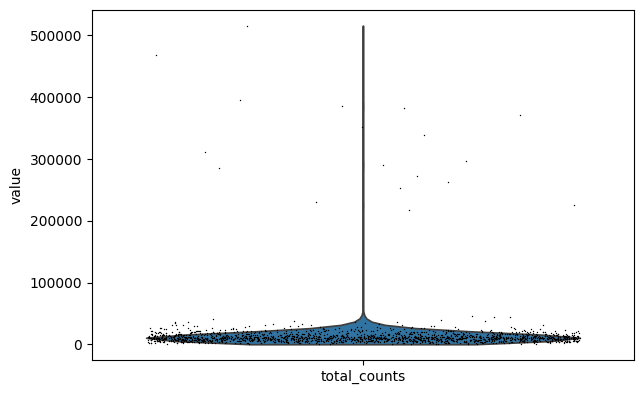

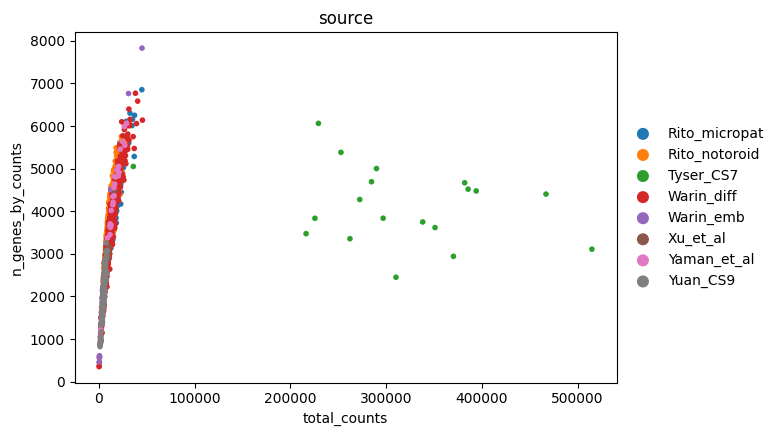

In [30]:
sc.pp.calculate_qc_metrics(adata, inplace=True)
sc.pl.violin(adata, 'total_counts', jitter=0.4)
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts',color='source')

# 2. PCA plots for review

In [31]:
adata


AnnData object with n_obs × n_vars = 1824 × 15944
    obs: 'sample_rito3D', 'Noto_review_rito3D', 'n_genes_rito2D', 'n_genes_by_counts_rito2D', 'total_counts_rito2D', 'total_counts_mt_rito2D', 'pct_counts_mt_rito2D', 'doublet_rito2D', 'doublet_score_rito2D', 'sample_rito2D', 'Noto_review_rito2D', 'cell_id_xu', 'cluster_id_xu', 'main_cluster_xu', 'annotation_xu', 'embryo_xu', 'stage_xu', 'dissection_part_xu', 'Noto_review_xu', 'sample_warin_diff', 'Noto_review_warin_diff', 'Noto_review_warin_emb', 'X0_tyser', 'X1_tyser', 'cluster_id_tyser', 'sub_cluster_tyser', 'cell_name_tyser', 'species_tyser', 'cell_type_tyser', 'Noto_review_tyser', 'Noto_review_yaman', 'Noto_review_yuanCS9', 'source', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids-1', 'feature_types-1', 'mt-1', 'n_cells_by_counts-0-1', 'mean_counts-0-1', '

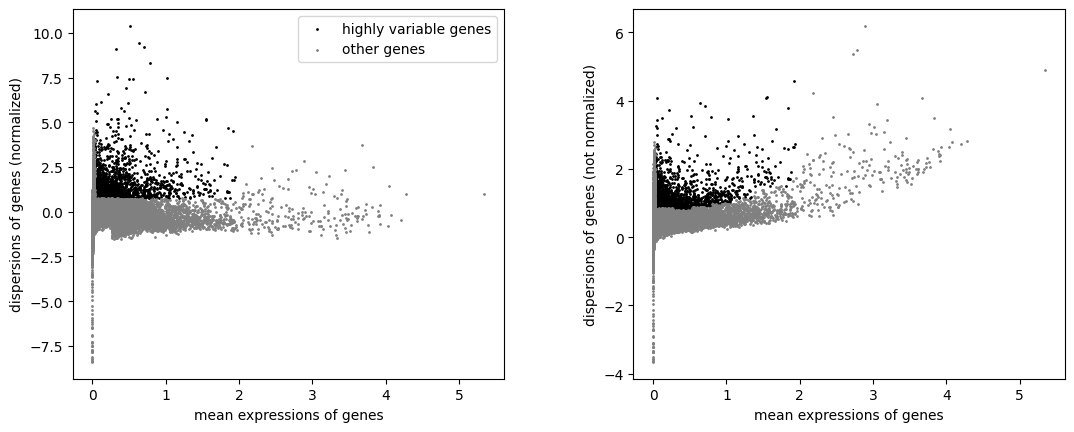

/nemo/lab/briscoej/home/users/ritot/single_cell/env2/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:657: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


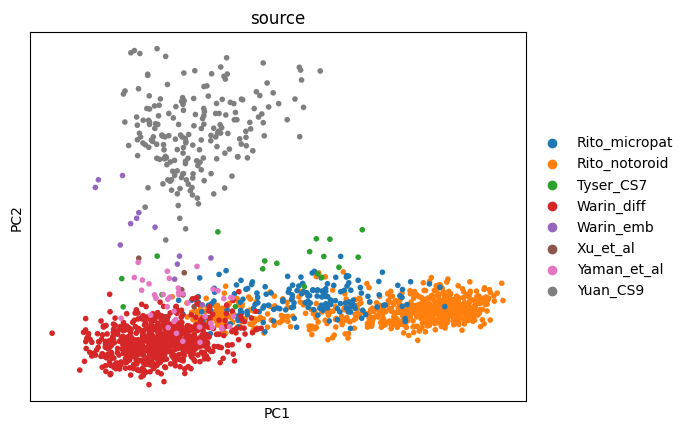

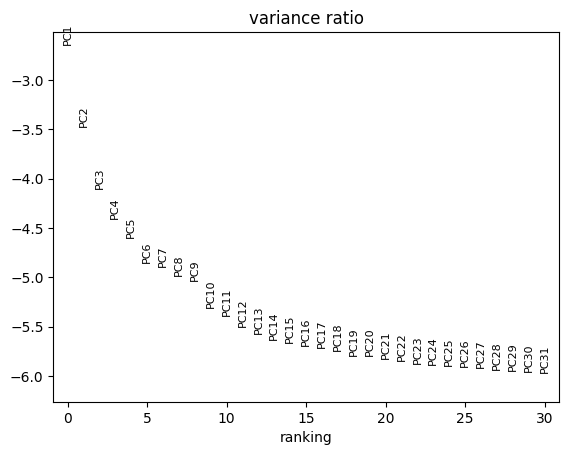

/nemo/lab/briscoej/home/users/ritot/single_cell/env2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/slurm_44827182/ipykernel_1306977/922833616.py:24: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, random_state=42, resolution=0.2)


,0,1
2,Rito_notoroid_0,1
7,Tyser_CS7_3,1
9,Warin_diff_2,1
12,Yaman_et_al_0,1
0,Rito_micropat_1,3
6,Tyser_CS7_2,4
11,Xu_et_al_0,7
10,Warin_emb_0,13
5,Tyser_CS7_1,14
13,Yaman_et_al_4,41


In [32]:
# scRNA-seq workflow to get clusters 

sc.pp.normalize_total(adata, target_sum=1e4, exclude_highly_expressed=True, max_fraction=0.03)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, min_mean=0.03, max_mean=2, min_disp=0.75)
sc.pl.highly_variable_genes(adata)

var_genes = adata.var.highly_variable

adata.raw = adata
adata = adata[:, var_genes]

sc.pp.regress_out(adata, ['total_counts'])
sc.pp.scale(adata, max_value=10)

sc.tl.pca(adata, svd_solver='arpack',random_state=42)
sc.pl.pca(adata, color='source')
sc.pl.pca_variance_ratio(adata, log=True)

sc.pp.neighbors(adata, n_pcs=20, n_neighbors=20, random_state=42)


sc.tl.leiden(adata, random_state=42, resolution=0.2)
adata.obs['heatmap_groups']=[x+"_"+y for x,y in zip(adata.obs['source'],adata.obs['leiden']) ]

pd.DataFrame(np.unique(adata.obs['heatmap_groups'],return_counts=True)).transpose().sort_values(by=1)


In [33]:
#variably genes which are differentially expressed in in vitro samples and present in embryo scRNA-seq
# to obtain these run MAST and make an flag indicating if expressed in embryos at any time-point

mast = pd.read_csv("./notochord_review_markers_MAST_one_vs_one.csv")
mast

gene_considered = pd.read_csv("./genes_considered.csv")
gene_considered = gene_considered[gene_considered["in_emb"]==True]

gene_considered = gene_considered[ [x in list(adata.raw.var_names)for x in gene_considered["gene_names"] ]]
len(gene_considered)

1489

In [34]:
gene_expr = pd.DataFrame(
    adata.raw[:, list(gene_considered['gene_names'])].X.toarray(), 
    index=adata.obs_names,
    columns=list(gene_considered['gene_names'])
)

In [35]:
# clusters with less than 5 cells are not considered in these analyses

group_counts = adata.obs['heatmap_groups'].value_counts()
valid_groups = group_counts[group_counts > 5].index


valid = [x in valid_groups for x in adata.obs.heatmap_groups ]


gene_expr = gene_expr[valid]
labels = adata.obs['heatmap_groups'].values[valid]

In [36]:
adata.obs['heatmap_groups'].value_counts()

heatmap_groups
Warin_diff_0       676
Rito_notoroid_1    554
Yuan_CS9_3         195
Rito_micropat_2    169
Rito_notoroid_2    144
Yaman_et_al_4       41
Tyser_CS7_1         14
Warin_emb_0         13
Xu_et_al_0           7
Tyser_CS7_2          4
Rito_micropat_1      3
Rito_notoroid_0      1
Warin_diff_2         1
Tyser_CS7_3          1
Yaman_et_al_0        1
Name: count, dtype: int64

In [37]:
valid_groups

Index(['Warin_diff_0', 'Rito_notoroid_1', 'Yuan_CS9_3', 'Rito_micropat_2',
       'Rito_notoroid_2', 'Yaman_et_al_4', 'Tyser_CS7_1', 'Warin_emb_0',
       'Xu_et_al_0'],
      dtype='object', name='heatmap_groups')

In [38]:

X=gene_expr
codes, uniques = pd.factorize(labels)
y = codes
targets = uniques
features = gene_expr.columns.values

pca = PCA(n_components=3, svd_solver='randomized', random_state=42).fit(X)
X_reduced = pca.transform(X)


scores = X_reduced[:, :2]
loadings = pca.components_[:2].T
pvars = pca.explained_variance_ratio_[:2] * 100


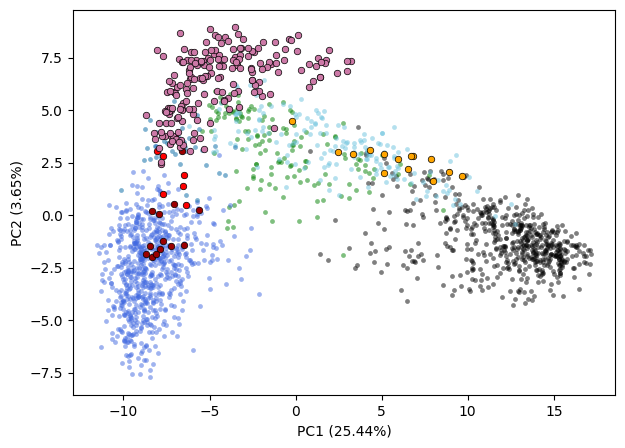

In [39]:
#in vitro VS in vivo
custom_colors = {
    'Rito_micropat_2':'#6BC3DE', 
    'Rito_notoroid_1':'black', 
    'Rito_notoroid_2':'green',
    'Warin_diff_0':'#4169e1',
    'Yaman_et_al_4':'#0066A3',
    'Xu_et_al_3':'salmon',
    'Tyser_CS7_1':'orange',
    'Xu_et_al_0':"red",
    'Warin_emb_0':"#9B0000",
    'Yuan_CS9_3':'#CC79A7'
}

emb_vitro = {
    'Rito_micropat_2':'vitro', 
    'Rito_notoroid_1':'vitro', 
    'Rito_notoroid_2':'vitro',
    'Warin_diff_0':'vitro',
    'Yaman_et_al_4':'vitro',
    'Xu_et_al_3':'emb',
    'Tyser_CS7_1':'emb',
    'Xu_et_al_0':"emb",
    'Warin_emb_0':"emb",
    'Yuan_CS9_3':'emb'
}


plt.figure(figsize=(7, 5))
for i, name in enumerate(targets):
    if emb_vitro[name]=='vitro':
        plt.scatter(*zip(*scores[y == i]), label=name, s=12 , alpha=0.5, color=custom_colors[name],linewidths=0)
    

for i, name in enumerate(targets):
    if emb_vitro[name]=='emb':
        plt.scatter(*zip(*scores[y == i]), label=name, s=22 , alpha=1, 
                    edgecolors='black',linewidths=0.5  ,
                    color=custom_colors[name])


width = -0.005 * np.min([np.subtract(*plt.xlim()), np.subtract(*plt.ylim())])

for i, axis in enumerate('xy'):
    getattr(plt, f'{axis}label')(f'PC{i + 1} ({pvars[i]:.2f}%)')


plt.show()


In [40]:
adata.obs['days']='NA'

adata.obs.loc[adata.obs['sample_rito3D']==0, "days"]='day3'
adata.obs.loc[adata.obs['sample_rito3D']==1, "days"]='day3'
adata.obs.loc[adata.obs['sample_rito3D']==2, "days"]='day5'
adata.obs.loc[adata.obs['sample_rito3D']==3, "days"]='day5'
adata.obs.loc[adata.obs['sample_rito3D']==4, "days"]='day7'
adata.obs.loc[adata.obs['sample_rito3D']==5, "days"]='day7'
adata.obs.loc[adata.obs['sample_rito3D']==6, "days"]='day7'

adata.obs.loc[adata.obs['source']=='Warin_diff', 'days']='day7'
adata.obs.loc[adata.obs['source']=='Rito_micropat','days']='day3'
adata.obs.loc[adata.obs['source']=='Yaman_et_al','days']='day5'

adata.obs.loc[adata.obs['source']=='Xu_et_al','days']='CS12-15'
adata.obs.loc[adata.obs['source']=='Tyser_CS7','days']='CS7'
adata.obs.loc[adata.obs['source']=='Warin_emb','days']='CS20'
adata.obs.loc[adata.obs['source']=='Yuan_CS9','days']='CS9'

/tmp/slurm_44827182/ipykernel_1306977/2458894376.py:15: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_filtered_clusters.obs['heatmap_groups'] = pd.Categorical(
/tmp/slurm_44827182/ipykernel_1306977/2458894376.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg = df.groupby(adata_filtered_clusters.obs['heatmap_groups']).mean()


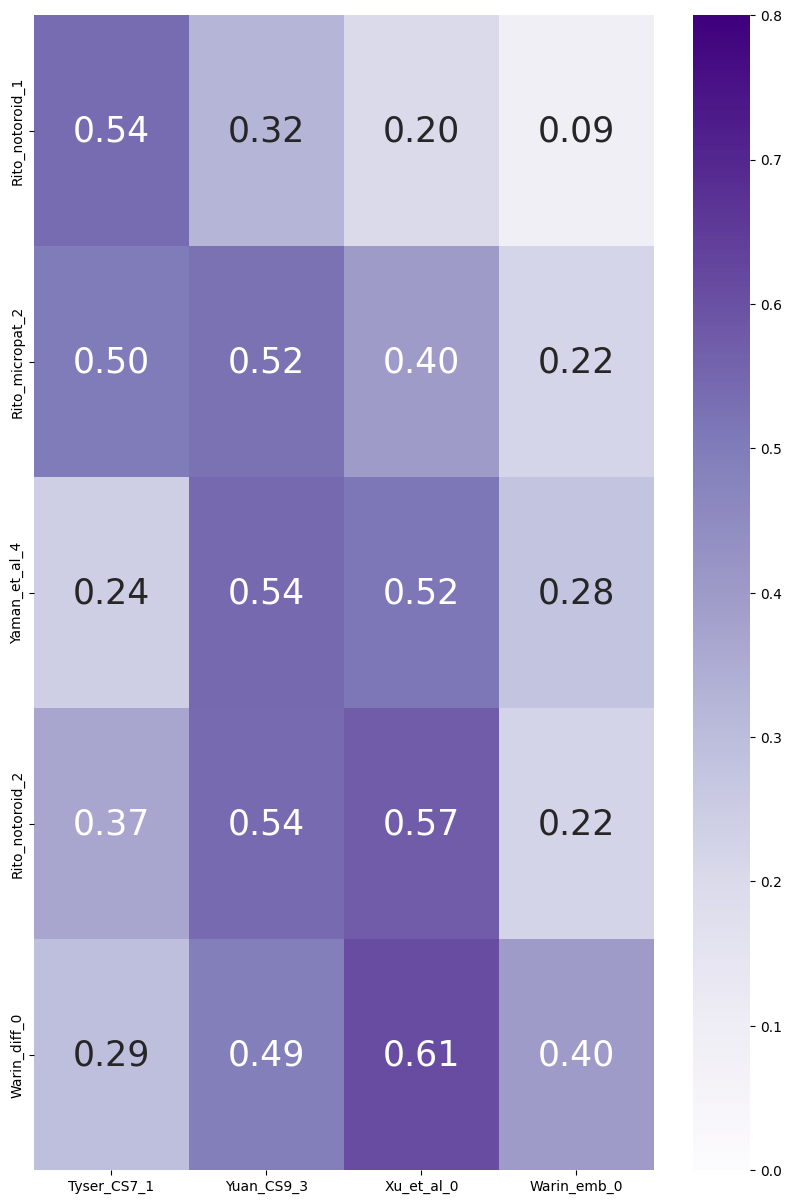

In [41]:
# Plot Heatmap

group_counts = adata.obs['heatmap_groups'].value_counts()
valid_groups = group_counts[group_counts > 5].index
valid = [x in valid_groups for x in adata.obs.heatmap_groups ]
adata_filtered_clusters=adata[valid]


embryos=['Tyser_CS7_1','Yuan_CS9_3','Xu_et_al_0','Warin_emb_0']
invitro=['Rito_notoroid_1','Rito_micropat_2','Yaman_et_al_4','Rito_notoroid_2', 'Warin_diff_0']
custom_order = ['Rito_notoroid_1', 'Rito_micropat_2', 'Yaman_et_al_4',
                'Rito_notoroid_2','Warin_diff_0',
       'Tyser_CS7_1', 'Yuan_CS9_3',   'Xu_et_al_0','Warin_emb_0']

adata_filtered_clusters.obs['heatmap_groups'] = pd.Categorical(
    adata_filtered_clusters.obs['heatmap_groups'],
    categories=custom_order,
    ordered=True
)



genes_raw_=[ x in list(adata.var_names) for x in list(adata_filtered_clusters.raw.var_names)]

X = adata_filtered_clusters.raw.X[:,genes_raw_].toarray()

a= np.asarray(adata_filtered_clusters.raw.var_names)
df = pd.DataFrame(X, index=np.asarray(adata_filtered_clusters.obs_names), columns=a[genes_raw_] )
avg = df.groupby(adata_filtered_clusters.obs['heatmap_groups']).mean()


corr_matrix = pd.DataFrame(index=embryos, columns=invitro, dtype=float)

for a in embryos:
    for b in invitro:
        corr, _ = pearsonr(avg.loc[a],avg.loc[b])
        corr_matrix.loc[a, b] = corr

plt.figure(figsize=(10, 15))
sns.heatmap(corr_matrix.astype(float).T, annot=True, cmap='Purples', vmin=0, vmax=0.8   ,fmt=".2f",annot_kws={"size": 25} )
plt.show()

In [42]:
corr_matrix

,Rito_notoroid_1,Rito_micropat_2,Yaman_et_al_4,Rito_notoroid_2,Warin_diff_0
Tyser_CS7_1,0.537793,0.500686,0.243302,0.367684,0.294856
Yuan_CS9_3,0.324937,0.524065,0.543812,0.543370,0.491061
Xu_et_al_0,0.199912,0.397404,0.515422,0.572306,0.611456
Warin_emb_0,0.085809,0.216073,0.275546,0.219974,0.397090


In [43]:
# Plot info bar about days of diff present in each cluster
adata_filtered_clusters.obs['days_sys']='NA'

adata_filtered_clusters.obs.loc[adata_filtered_clusters.obs['sample_rito3D']==0, "days_sys"]='day3_notoroid'
adata_filtered_clusters.obs.loc[adata_filtered_clusters.obs['sample_rito3D']==1, "days_sys"]='day3_notoroid'
adata_filtered_clusters.obs.loc[adata_filtered_clusters.obs['sample_rito3D']==2, "days_sys"]='day5_notoroid'
adata_filtered_clusters.obs.loc[adata_filtered_clusters.obs['sample_rito3D']==3, "days_sys"]='day5_notoroid'
adata_filtered_clusters.obs.loc[adata_filtered_clusters.obs['sample_rito3D']==4, "days_sys"]='day7_notoroid'
adata_filtered_clusters.obs.loc[adata_filtered_clusters.obs['sample_rito3D']==5, "days_sys"]='day7_notoroid'
adata_filtered_clusters.obs.loc[adata_filtered_clusters.obs['sample_rito3D']==6, "days_sys"]='day7_notoroid'

adata_filtered_clusters.obs.loc[adata_filtered_clusters.obs['source']=='Warin_diff', 'days_sys']='day7_Warin_diff'
adata_filtered_clusters.obs.loc[adata_filtered_clusters.obs['source']=='Rito_micropat','days_sys']='day3_micropattern'
adata_filtered_clusters.obs.loc[adata_filtered_clusters.obs['source']=='Yaman_et_al','days_sys']='day5_Yaman'

adata_filtered_clusters.obs.loc[adata_filtered_clusters.obs['source']=='Xu_et_al','days_sys']='CS12-15'
adata_filtered_clusters.obs.loc[adata_filtered_clusters.obs['source']=='Tyser_CS7','days_sys']='CS7'
adata_filtered_clusters.obs.loc[adata_filtered_clusters.obs['source']=='Warin_emb','days_sys']='CS20'
adata_filtered_clusters.obs.loc[adata_filtered_clusters.obs['source']=='Yuan_CS9','days_sys']='CS9'



for i in np.unique(adata_filtered_clusters.obs['heatmap_groups']):
    print(i)
    print(np.unique(adata_filtered_clusters.obs['days_sys'][adata_filtered_clusters.obs['heatmap_groups']==i], return_counts=True))
    

Rito_micropat_2
(array(['day3_micropattern'], dtype=object), array([169]))
Rito_notoroid_1
(array(['day3_notoroid', 'day5_notoroid'], dtype=object), array([549,   5]))
Rito_notoroid_2
(array(['day3_notoroid', 'day5_notoroid', 'day7_notoroid'], dtype=object), array([74, 66,  4]))
Tyser_CS7_1
(array(['CS7'], dtype=object), array([14]))
Warin_diff_0
(array(['day7_Warin_diff'], dtype=object), array([676]))
Warin_emb_0
(array(['CS20'], dtype=object), array([13]))
Xu_et_al_0
(array(['CS12-15'], dtype=object), array([7]))
Yaman_et_al_4
(array(['day5_Yaman'], dtype=object), array([41]))
Yuan_CS9_3
(array(['CS9'], dtype=object), array([195]))


In [44]:
invitro = ['Rito_notoroid_1', 'Rito_micropat_2', 'Yaman_et_al_4', 'Rito_notoroid_2', 'Warin_diff_0']
days = ['day3', 'day5', 'day7']

records = []
for group in invitro:
    mask = adata_filtered_clusters.obs['heatmap_groups'] == group
    unique_days, counts = np.unique(
        adata_filtered_clusters.obs['days_sys'][mask], 
        return_counts=True
    )
    day_counts = dict(zip(unique_days, counts))
    
    for day in days:
        # Match day prefix 
        matched = sum(v for k, v in day_counts.items() if k.startswith(day))
        records.append({'data': group, 'days': day, 'vals': matched})

df = pd.DataFrame(records)
df

,data,days,vals
0,Rito_notoroid_1,day3,549
1,Rito_notoroid_1,day5,5
2,Rito_notoroid_1,day7,0
3,Rito_micropat_2,day3,169
4,Rito_micropat_2,day5,0
5,Rito_micropat_2,day7,0
6,Yaman_et_al_4,day3,0
7,Yaman_et_al_4,day5,41
8,Yaman_et_al_4,day7,0
9,Rito_notoroid_2,day3,74


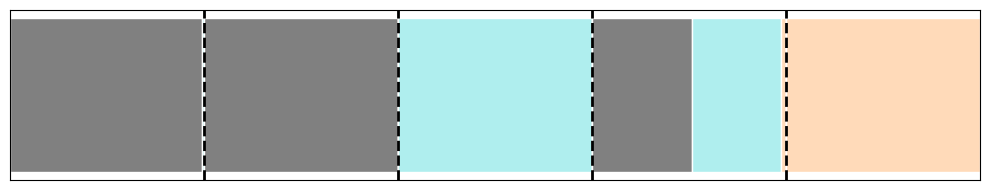

In [45]:
# Flatten for single bar
cluster_order = df['data'].drop_duplicates().tolist()
day_order = df['days'].drop_duplicates().tolist()

pivot = df.pivot(index='data', columns='days', values='vals').fillna(0)

# Convert counts to percent
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct.reindex(index=cluster_order, columns=day_order)


values = []
colors = []
labels = []
color_dict = {
    'day3': 'gray',
    'day5': 'paleturquoise',
    'day7': 'peachpuff'
}

for cluster in cluster_order:
    for day in day_order:
        val = pivot_pct.loc[cluster, day]
        values.append(val)
        colors.append(color_dict[day])
        labels.append(f"{cluster}-{day}")

# Create a single horiz bar 
fig, ax = plt.subplots(figsize=(10,2))

left = 0
for i, (v, c, lab) in enumerate(zip(values, colors, labels)):
    ax.barh(0, v, left=left, color=c, edgecolor='white', height=0.5)
    left += v

cluster_positions = np.cumsum([pivot_pct.loc[cl].sum() for cl in cluster_order])
for pos in cluster_positions[:-1]:  # exclude the last border
    ax.axvline(pos, color='black', linestyle='--', lw=2)


ax.set_yticks([])
ax.set_xlim(0, 100*len(cluster_order))
ax.set_xticks([])

from matplotlib.patches import Patch
legend_handles = [Patch(color=color_dict[d], label=d) for d in day_order]
plt.tight_layout()
plt.show()


In [46]:
pivot_pct

days,day3,day5,day7
data,,,
Rito_notoroid_1,99.097473,0.902527,0.000000
Rito_micropat_2,100.000000,0.000000,0.000000
Yaman_et_al_4,0.000000,100.000000,0.000000
Rito_notoroid_2,51.388889,45.833333,2.777778
Warin_diff_0,0.000000,0.000000,100.000000
